In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv('../data/processed/telco_limpio.csv')

# Separar variables predictoras del objetivo
X = df.drop(columns=['customerID', 'Churn'])
y = (df['Churn'] == 'Yes').astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(X_train.shape, X_test.shape)
print(y_train.mean(), y_test.mean())

(5625, 20) (1407, 20)
0.2657777777777778 0.2658137882018479


## Cómo leer un histograma

Un histograma agrupa los valores en intervalos (bins) y muestra cuántos
registros caen en cada uno. El eje X es el valor, el eje Y la frecuencia.

### Formas típicas

**Simétrica (campana)**
Los valores se agrupan en el centro y decrecen parejo hacia ambos lados.
La media y la mediana coinciden. Skew ≈ 0.

**Sesgada a la derecha (cola derecha)**
Montaña pegada a la izquierda, cola larga hacia la derecha.
Muchos valores pequeños, pocos muy grandes.
La media queda por encima de la mediana, arrastrada por los extremos.
Skew > 0. Típico en dinero, ingresos, montos de contratos.

**Sesgada a la izquierda (cola izquierda)**
Lo contrario: cola larga hacia valores bajos. Skew < 0.

**Bimodal (dos picos)**
Dos concentraciones separadas. Casi siempre indica dos poblaciones
distintas mezcladas en la misma variable.
El skew NO detecta esto: puede dar cerca de 0 y la variable no ser normal.

**Uniforme**
Barras de altura parecida en todo el rango. Sin concentración.

### La cola

La cola es la parte donde las barras son bajas pero se extienden.
Contiene pocos registros con valores extremos.
Una cola larga significa que hay valores muy alejados del grueso de los datos.

Esos extremos inflan la media y la desviación estándar, y arrastran
a los modelos lineales.

### Qué hacer según la forma

| Forma | Acción |
|---|---|
| Simétrica | Estandarizar (z-score) |
| Sesgo moderado (skew 1–2) | Evaluar log; probar con y sin |
| Sesgo fuerte (skew > 2) | Log antes de estandarizar |
| Bimodal | No transformar; investigar qué separa los grupos |
| Cola con pocos casos extremos | Revisar si son errores o casos reales |

### Regla de interpretación del skew

- |skew| < 0,5 → aproximadamente simétrica
- 0,5 a 1 → sesgo leve
- 1 a 2 → sesgo moderado
- > 2 → sesgo fuerte

### Advertencia

El skew resume la asimetría en un número, pero no describe la forma.
Una distribución bimodal puede tener skew cercano a 0.
Siempre mirar el gráfico antes de decidir con el número.

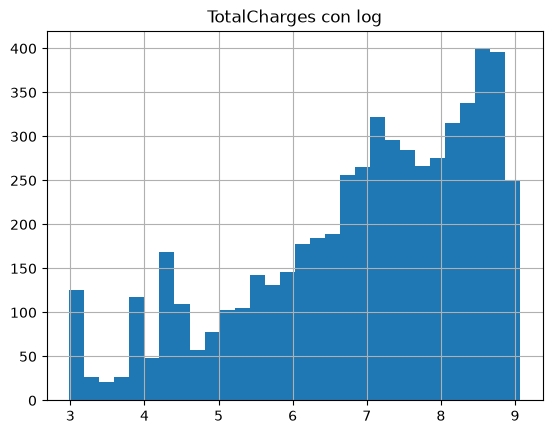

-0.7535387396806247


In [4]:
import numpy as np

np.log1p(X_train['TotalCharges']).hist(bins=30)
plt.title('TotalCharges con log')
plt.show()

print(np.log1p(X_train['TotalCharges']).skew())

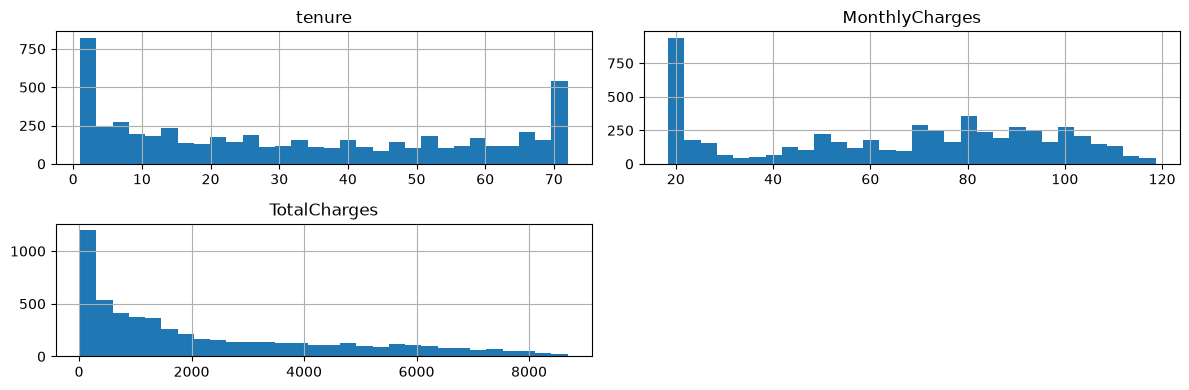

tenure            0.237016
MonthlyCharges   -0.230273
TotalCharges      0.954139
dtype: float64


In [5]:
import matplotlib.pyplot as plt

X_train[['tenure', 'MonthlyCharges', 'TotalCharges']].hist(figsize=(12,4), bins=30)
plt.tight_layout()
plt.show()

print(X_train[['tenure', 'MonthlyCharges', 'TotalCharges']].skew())

In [6]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression

num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
cat_cols = [c for c in X_train.columns 
            if c not in num_cols + ['mes_a_mes_fibra']]

preprocesador = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(drop='if_binary', handle_unknown='ignore'), cat_cols)
], remainder='passthrough')

modelo = Pipeline([
    ('prep', preprocesador),
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

modelo.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](20,)","['gender','SeniorCitizen','Partner',...,'MonthlyCharges','TotalCharges', 'mes_a_mes_fibra']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,20
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthroug

In [7]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = modelo.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[723 310]
 [ 74 300]]
              precision    recall  f1-score   support

           0       0.91      0.70      0.79      1033
           1       0.49      0.80      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.80      0.73      0.74      1407



In [8]:
probabilidades = modelo.predict_proba(X_test)[:, 1]

resultado = X_test.copy()
resultado['prob_churn'] = probabilidades
resultado = resultado.sort_values('prob_churn', ascending=False)

resultado[['tenure', 'Contract', 'InternetService', 'MonthlyCharges', 'prob_churn']].head(20)

,tenure,Contract,InternetService,MonthlyCharges,prob_churn
3154,3,Month-to-month,Fiber optic,94.85,0.934593
3374,1,Month-to-month,Fiber optic,95.10,0.934564
2626,7,Month-to-month,Fiber optic,99.25,0.924575
4577,1,Month-to-month,Fiber optic,85.05,0.922453
3721,3,Month-to-month,Fiber optic,96.60,0.919845
2792,3,Month-to-month,Fiber optic,100.95,0.919792
581,4,Month-to-month,Fiber optic,89.20,0.917447
931,4,Month-to-month,Fiber optic,84.60,0.916781
2511,16,Month-to-month,Fiber optic,96.40,0.910649
6231,1,Month-to-month,Fiber optic,93.30,0.907265


In [9]:
alto = resultado[resultado['prob_churn'] > 0.8]
medio = resultado[(resultado['prob_churn'] > 0.5) & (resultado['prob_churn'] <= 0.8)]

print(f"Alto riesgo: {len(alto)}")
print(f"Riesgo medio: {len(medio)}")

Alto riesgo: 211
Riesgo medio: 399


In [10]:
import numpy as np

nombres = modelo.named_steps['prep'].get_feature_names_out()
pesos = modelo.named_steps['clf'].coef_[0]

coef = pd.DataFrame({'variable': nombres, 'peso': pesos})
coef['abs'] = coef['peso'].abs()
coef = coef.sort_values('abs', ascending=False)

coef[['variable', 'peso']].head(15)

,variable,peso
0,num__tenure,-1.215316
11,cat__InternetService_No,-1.143336
10,cat__InternetService_Fiber optic,0.876926
20,cat__Contract_Two year,-0.871446
18,cat__Contract_Month-to-month,0.649122
2,num__TotalCharges,0.561717
7,cat__PhoneService_Yes,-0.436284
12,cat__OnlineSecurity_Yes,-0.379059
15,cat__TechSupport_Yes,-0.337446
16,cat__StreamingTV_Yes,0.317467


"se elimina TotalCharges por ser producto de tenure y MonthlyCharges; al removerla el recall pasó de 0,80 a 0,79 sin pérdida material, ganando estabilidad en los coeficientes"

In [11]:
from sklearn.metrics import classification_report

num_cols_sin = ['tenure', 'MonthlyCharges']
X_train2 = X_train.drop(columns=['TotalCharges'])
X_test2 = X_test.drop(columns=['TotalCharges'])

prep2 = ColumnTransformer([
    ('num', StandardScaler(), num_cols_sin),
    ('cat', OneHotEncoder(drop='if_binary', handle_unknown='ignore'), cat_cols)
], remainder='passthrough')

modelo2 = Pipeline([
    ('prep', prep2),
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

modelo2.fit(X_train2, y_train)
y_pred2 = modelo2.predict(X_test2)
print(classification_report(y_test, y_pred2))

              precision    recall  f1-score   support

           0       0.90      0.71      0.79      1033
           1       0.49      0.79      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.73      0.74      1407



In [12]:
nombres2 = modelo2.named_steps['prep'].get_feature_names_out()
pesos2 = modelo2.named_steps['clf'].coef_[0]

coef2 = pd.DataFrame({'variable': nombres2, 'peso': pesos2})
coef2['abs'] = coef2['peso'].abs()
coef2.sort_values('abs', ascending=False)[['variable','peso']].head(10)

,variable,peso
10,cat__InternetService_No,-1.157898
9,cat__InternetService_Fiber optic,1.011402
19,cat__Contract_Two year,-0.909744
0,num__tenure,-0.767498
17,cat__Contract_Month-to-month,0.740053
6,cat__PhoneService_Yes,-0.412903
25,remainder__mes_a_mes_fibra,-0.404160
11,cat__OnlineSecurity_Yes,-0.365334
15,cat__StreamingTV_Yes,0.334671
7,cat__MultipleLines_Yes,0.334664


Y hay algo que te va a interesar: mes_a_mes_fibra salió con −0,40.

Negativo. Tu feature de interacción está reduciendo la probabilidad de churn, cuando la creaste esperando lo contrario.

Por qué: el modelo ya suma fibra (+1,01) y mes a mes (+0,74). Un cliente con ambas acumula +1,75. Aparentemente eso se pasa, y el término de interacción corrige hacia abajo.

Traducción: el efecto combinado es menor que la suma de las partes. Fibra y mes a mes no se potencian — se solapan. Parte de lo que parecía efecto de la fibra ya estaba capturado por el contrato.

Eso contradice la interpretación que hicimos del EDA. Y el modelo tiene la razón, por lo mismo de antes: el EDA mira de a dos variables, el modelo controla por las otras 25.

In [13]:
X_train3 = X_train.drop(columns=['TotalCharges', 'mes_a_mes_fibra'])
X_test3 = X_test.drop(columns=['TotalCharges', 'mes_a_mes_fibra'])

cat_cols3 = [c for c in X_train3.columns if c not in ['tenure', 'MonthlyCharges']]

prep3 = ColumnTransformer([
    ('num', StandardScaler(), ['tenure', 'MonthlyCharges']),
    ('cat', OneHotEncoder(drop='if_binary', handle_unknown='ignore'), cat_cols3)
])

modelo3 = Pipeline([
    ('prep', prep3),
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

modelo3.fit(X_train3, y_train)
print(classification_report(y_test, modelo3.predict(X_test3)))

              precision    recall  f1-score   support

           0       0.90      0.71      0.79      1033
           1       0.49      0.78      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.73      0.74      1407



In [18]:
nombres3 = modelo3.named_steps['prep'].get_feature_names_out()
pesos3 = modelo3.named_steps['clf'].coef_[0]

coef3 = pd.DataFrame({'variable': nombres3, 'peso': pesos3})
coef3['abs'] = coef3['peso'].abs()
coef3.sort_values('abs', ascending=False)[['variable','peso']].head(10)

,variable,peso
10,cat__InternetService_No,-1.104601
19,cat__Contract_Two year,-0.858462
9,cat__InternetService_Fiber optic,0.829749
0,num__tenure,-0.752571
17,cat__Contract_Month-to-month,0.600237
6,cat__PhoneService_Yes,-0.370077
11,cat__OnlineSecurity_Yes,-0.358574
15,cat__StreamingTV_Yes,0.356874
16,cat__StreamingMovies_Yes,0.341825
7,cat__MultipleLines_Yes,0.329269


In [14]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(modelo3, X_train3, y_train, cv=5, scoring='recall')
print(scores, scores.mean())

[0.7993311  0.81270903 0.80267559 0.72240803 0.8361204 ] 0.7946488294314381


In [15]:
from sklearn.ensemble import RandomForestClassifier

modelo_rf = Pipeline([
    ('prep', prep3),
    ('clf', RandomForestClassifier(
        n_estimators=300,
        class_weight='balanced',
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    ))
])

scores_rf = cross_val_score(modelo_rf, X_train3, y_train, cv=5, scoring='recall')
print("Random Forest:", scores_rf, scores_rf.mean())
print("Logística:    0.7946")

Random Forest: [0.76923077 0.80936455 0.76923077 0.71906355 0.79598662] 0.7725752508361203
Logística:    0.7946


In [16]:
modelo_rf.fit(X_train3, y_train)
importancias = pd.DataFrame({
    'variable': modelo_rf.named_steps['prep'].get_feature_names_out(),
    'importancia': modelo_rf.named_steps['clf'].feature_importances_
}).sort_values('importancia', ascending=False)

importancias.head(10)

,variable,importancia
0,num__tenure,0.194751
17,cat__Contract_Month-to-month,0.164157
1,num__MonthlyCharges,0.126552
19,cat__Contract_Two year,0.086574
9,cat__InternetService_Fiber optic,0.064911
23,cat__PaymentMethod_Electronic check,0.054943
10,cat__InternetService_No,0.035676
18,cat__Contract_One year,0.034029
11,cat__OnlineSecurity_Yes,0.027534
20,cat__PaperlessBilling_Yes,0.020706


In [17]:
df.groupby('PaymentMethod')['Churn'].value_counts(normalize=True)

PaymentMethod              Churn
Bank transfer (automatic)  No       0.832685
                           Yes      0.167315
Credit card (automatic)    No       0.847469
                           Yes      0.152531
Electronic check           No       0.547146
                           Yes      0.452854
Mailed check               No       0.807980
                           Yes      0.192020
Name: proportion, dtype: float64